# 16 The Four Gates, Forward and One Step

| | |
|---|---|
| **Path** | Multilayer perceptron |
| **Prerequisite** | 15 |

The running table, gathered.

Two hidden units,

$$
h_1 = \mathrm{ReLU}(x_1 + x_2), \qquad
h_2 = \mathrm{ReLU}(x_1 + x_2 - 1)
$$

and output $h_1 - 2h_2$, score the gates as $0, 1, 1, 0$. That is XOR. The bend is the line $x_1 + x_2 = 1$. One hidden unit cannot produce the same four numbers, and two straight layers cannot either: without the bend, gate 00 scores $2$.

Move the second output weight from $-2$ to $-1$. The scores become $0, 1, 1, 1$. Total squared loss $1/2$, all of it on gate 11. The batch gradient of $(v_1, v_2, c)$ is

$$
(2,\, 1,\, 1)
$$

Step $1/8$ reaches

$$
\left(\dfrac{3}{4},\, -\dfrac{9}{8},\, -\dfrac{1}{8}\right)
$$

and total loss $23/128$. Step $1/4$ reaches loss $23/32$, which is worse than the start. The chain rule fixed the direction. The step size fixed the result.


## Example 1 — Solved forward pass, then the helpful step


In [1]:
# Solved scores are the targets. The step of 1/8 then lowers loss from 1/2 to 23/128.
from fractions import Fraction

def relu(value):
    return value if value > 0 else Fraction(0)

gates = [(0, 0), (1, 0), (0, 1), (1, 1)]
targets = [0, 1, 1, 0]
solved = []
for x1, x2 in gates:
    h1 = relu(x1 + x2)
    h2 = relu(x1 + x2 - 1)
    solved.append(h1 - 2 * h2)
print(solved)
assert solved == targets

v1, v2, c = Fraction(3, 4), Fraction(-9, 8), Fraction(-1, 8)
loss = 0
stepped = []
for (x1, x2), target in zip(gates, targets):
    h1 = relu(x1 + x2)
    h2 = relu(x1 + x2 - 1)
    score = v1 * h1 + v2 * h2 + c
    stepped.append(score)
    loss += Fraction(1, 2) * (score - target) ** 2
print(stepped, loss)
assert stepped == [Fraction(-1, 8), Fraction(5, 8), Fraction(5, 8), Fraction(1, 4)]
assert loss == Fraction(23, 128)


[Fraction(0, 1), Fraction(1, 1), Fraction(1, 1), 0]
[Fraction(-1, 8), Fraction(5, 8), Fraction(5, 8), Fraction(1, 4)] 23/128


## Example 2 — The bend, once more

Pass gates sit on the blue segment. The two fail gates sit on opposite sides of it.


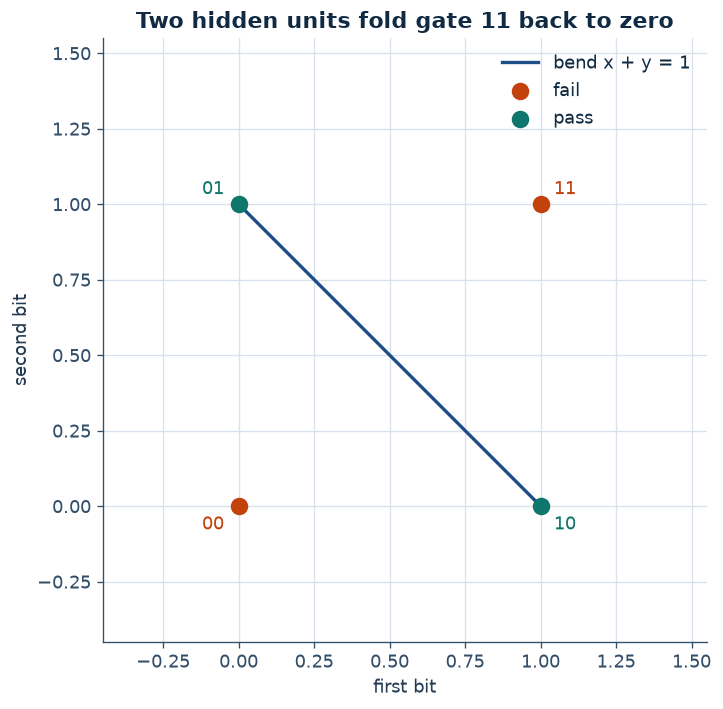

In [2]:
import matplotlib.pyplot as plt

# Pass is green, fail is clay, and the bend or the helpful step is blue or green.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# The same bend as lesson 05: the segment from (0, 1) to (1, 0).
fig, ax = plt.subplots(figsize=(6.4, 5.8), constrained_layout=True)
ax.plot([0, 1], [1, 0], color=BLUE, linewidth=2, label="bend x + y = 1", zorder=2)
ax.scatter([0, 1], [0, 1], s=90, color=CLAY, zorder=3, label="fail")
ax.scatter([1, 0], [0, 1], s=90, color=GREEN, zorder=3, label="pass")
ax.annotate("00", (0, 0), textcoords="offset points", xytext=(-22, -14), color=CLAY)
ax.annotate("10", (1, 0), textcoords="offset points", xytext=(8, -14), color=GREEN)
ax.annotate("01", (0, 1), textcoords="offset points", xytext=(-22, 6), color=GREEN)
ax.annotate("11", (1, 1), textcoords="offset points", xytext=(8, 6), color=CLAY)
ax.set_xlim(-0.45, 1.55)
ax.set_ylim(-0.45, 1.55)
ax.set_aspect("equal")
ax.set_xlabel("first bit")
ax.set_ylabel("second bit")
ax.set_title("Two hidden units fold gate 11 back to zero")
ax.legend(frameon=False)


## Pitfall — Loss $23/128$ is not a solved table

The solved network has loss $0$. After the helpful step the four scores are $-1/8$, $5/8$, $5/8$, and $1/4$. Every gate is now slightly wrong. The step improved the total and did not finish the job. Finishing, on this hidden layer, is the output weight $-2$ we started from, not the first gradient step away from $-1$.


## Summary

A multilayer perceptron is a stack of scores with a bend between them. Without the bend, the stack collapses to one line and gate 00 scores $2$. With ReLU, $h_1 - 2h_2$ matches XOR. One hidden unit cannot. The chain rule multiplies the residual by the forward values and by the ReLU slopes; a dead unit stops that product. Identical units stay identical. At the perturbed output weights, step $1/8$ moves the loss from $1/2$ to $23/128$, and step $1/4$ moves it to $23/32$.
